In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
titanic = sns.load_dataset("titanic")
print(titanic.shape)
titanic.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.info()
titanic.describe()
titanic["survived"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [4]:
titanic.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

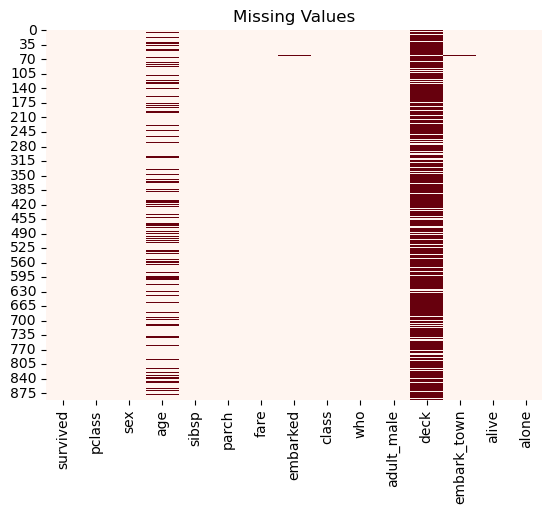

In [5]:
sns.heatmap(titanic.isnull(), cbar=False, cmap="Reds")
plt.title("Missing Values")
plt.show()

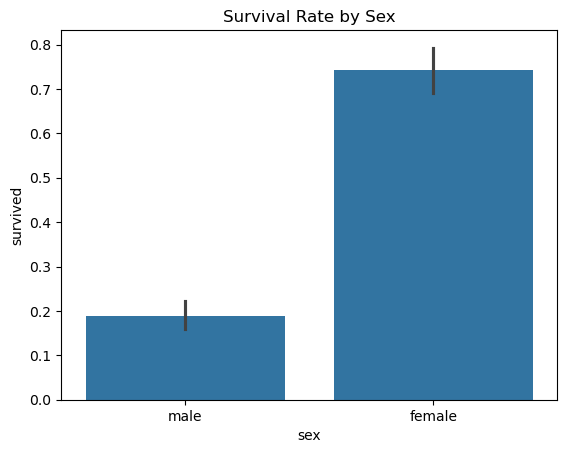

In [6]:
sns.barplot(data=titanic, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.show()

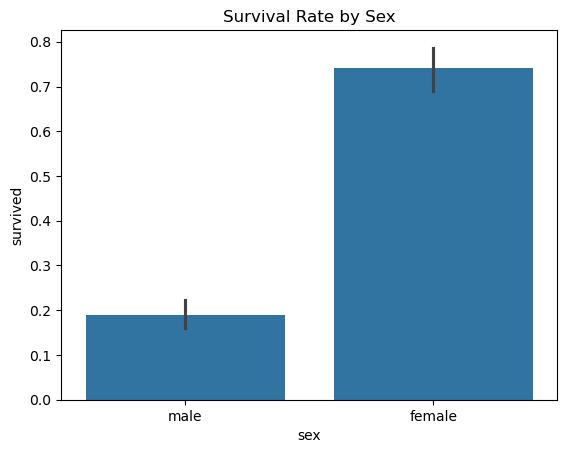

In [7]:
sns.barplot(data=titanic, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.show()

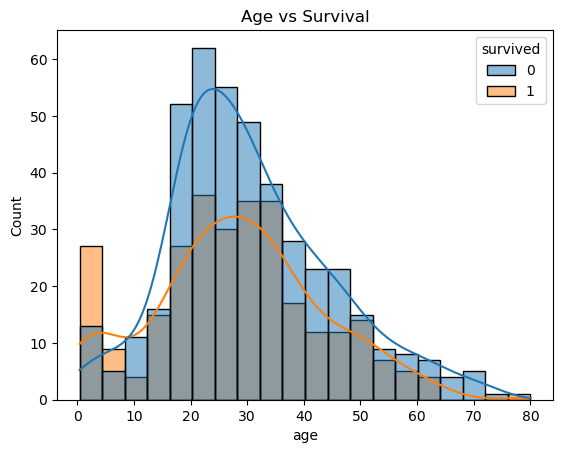

In [8]:
sns.histplot(data=titanic, x="age", hue="survived", kde=True)
plt.title("Age vs Survival")
plt.show()

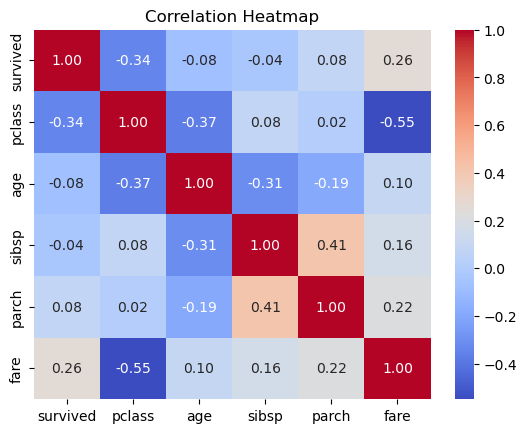

In [9]:
cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
cols = [c.strip() for c in cols]
sns.heatmap(titanic[cols].corr(), annot=True, fmt=".2f",
cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Report written to titanic_eda_report.pdf


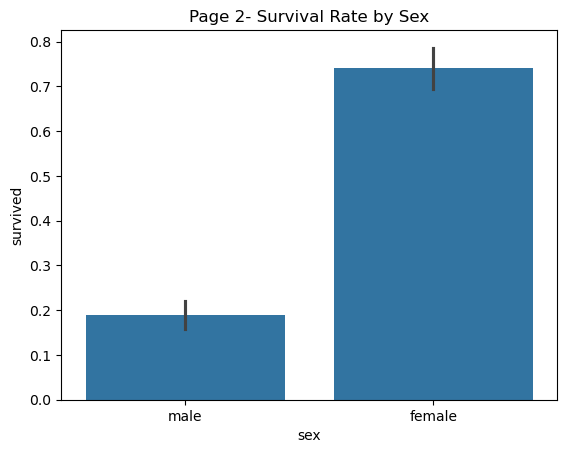

In [10]:
def titanic_eda_report(df, path="titanic_eda_report.pdf"):

  pdf = PdfPages(path)
# Page 1- missing values
  plt.figure(figsize=(11, 6))
  sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
  plt.title("Page 1- Missing Values")
  pdf.savefig()
  plt.close()
# Page 2- survival by sex
  plt.figure(figsize=(11, 6))
  pdf.savefig()
  plt.close()
  sns.barplot(data=df, x="sex", y="survived")
  plt.title("Page 2- Survival Rate by Sex")
# Page 3- correlation
  cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
  plt.figure(figsize=(11, 6))
  sns.heatmap(df[cols].corr(), annot=True, fmt=".2f",
  cmap="coolwarm")
  plt.title("Page 3- Correlation Heatmap")
  pdf.savefig()
  plt.close()
  pdf.close()
  print("Report written to", path)
titanic_eda_report(titanic)